# Evaluation - Explainability gallery

Per-pipeline explanations on shared examples: Grad-CAM for the CNNs, attention rollout for the ViT, embedding t-SNE for CLIP-probe, plus the frequency-spectrum motivation.

**Sections:** 0 Setup - 1 Grad-CAM gallery (CNNs) - 2 ViT attention rollout - 3 CLIP-probe t-SNE - 4 Notes

> Reads each pipeline's committed artifacts and reconstructs trained models via `utils.eval_protocols` (rebuilt from `best_params.json`). Run after training completes.

## 0 - Setup

In [5]:
import sys, json, math
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

_here = Path.cwd()
_nb = _here if (_here / "utils").is_dir() else _here / "notebooks"
if str(_nb) not in sys.path:
    sys.path.insert(0, str(_nb))

from utils import eval_protocols as EP, metrics as Me, viz as V, datasets as D, explain as E, eda

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT = EP.ART / "evaluation" / "figures"
OUT.mkdir(parents=True, exist_ok=True)
TAB = EP.ART / "evaluation"
PIPES = EP.available()
print("device:", device)
print("pipelines with trained results:", PIPES)
test_df = pd.read_csv(EP.SPLIT); test_df = test_df[test_df["keep"]]
test_df = test_df[test_df["split_final"] == "test"].reset_index(drop=True)
examples = E.pick_examples(test_df, n_per_class=2, seed=0)

def target_layers(name, model):
    if name == "cnn-scratch":   return [model.features[-1]]
    if name == "cnn-residual":  return [model.stages[-1]]
    if name == "srm-noise":     return [model.body.features[-1]]
    if name in ("two-stream", "freqcross"): return [model.spatial.features[-1]]
    if name == "cnn-finetune":
        return [model.layer4[-1]] if hasattr(model, "layer4") else [model.conv_head]
    return None

device: cuda
pipelines with trained results: ['cnn-scratch', 'cnn-residual', 'cnn-finetune', 'vit-lora', 'clip-probe', 'two-stream', 'freqcross', 'srm-noise', 'patch-ensemble', 'dire-recon']


## 1 - Grad-CAM gallery (CNN pipelines)

One row per pipeline, columns = shared example images (top label = true class, overlay = where the model looked).

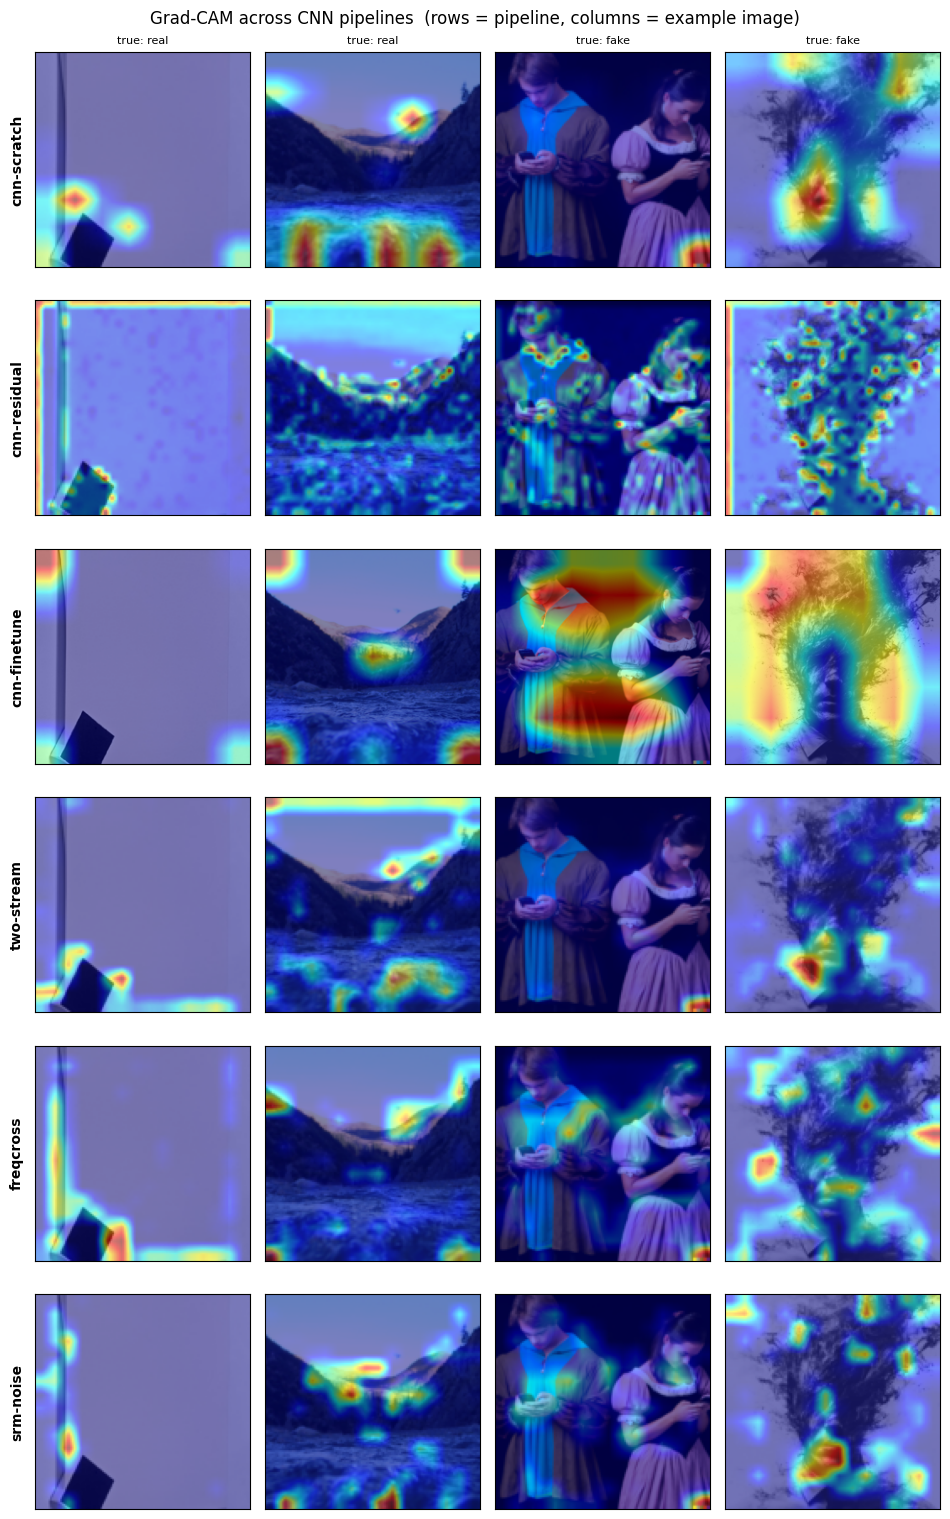

In [6]:
CAM_PIPES = [n for n in PIPES if n in ("cnn-scratch", "cnn-residual", "cnn-finetune", "srm-noise", "two-stream", "freqcross")]
fig, axes = plt.subplots(len(CAM_PIPES), len(examples), figsize=(2.4 * len(examples), 2.6 * len(CAM_PIPES)))
axes = np.array(axes).reshape(len(CAM_PIPES), len(examples))
for r, n in enumerate(CAM_PIPES):
    sp = EP.SPEC[n]; mean, std = D.resolve_stats(sp["norm"], EP.AIR)
    eval_tf = D.build_eval_tf(sp["size"], mean, std)
    model = EP.load_model(n, device); tls = target_layers(n, model)
    for col, ex in enumerate(examples):
        arr = eda.read_rgb(ex["filepath"]); xt = eval_tf(torch.from_numpy(arr).permute(2, 0, 1)); x = xt.unsqueeze(0).to(device)
        rgb = D.denormalize(xt, mean, std).permute(1, 2, 0).numpy()
        overlay = E.gradcam_overlay(model, tls, x, rgb)
        ax = axes[r, col]
        ax.imshow(overlay)
        ax.set_xticks([]); ax.set_yticks([])          # keep the frame (NOT axis('off')) so the row ylabel stays visible
        if r == 0:
            ax.set_title(f"true: {ex['label']}", fontsize=8)   # column header (top row only) = example's true class
    axes[r, 0].set_ylabel(n, fontsize=10, fontweight="bold", rotation=90, labelpad=8)  # row label = pipeline name
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
fig.suptitle("Grad-CAM across CNN pipelines  (rows = pipeline, columns = example image)", fontsize=12)
fig.tight_layout()
fig.savefig(OUT / "gradcam_gallery.png", dpi=150, bbox_inches="tight"); plt.show()

## 2 - ViT attention rollout (vit-lora)

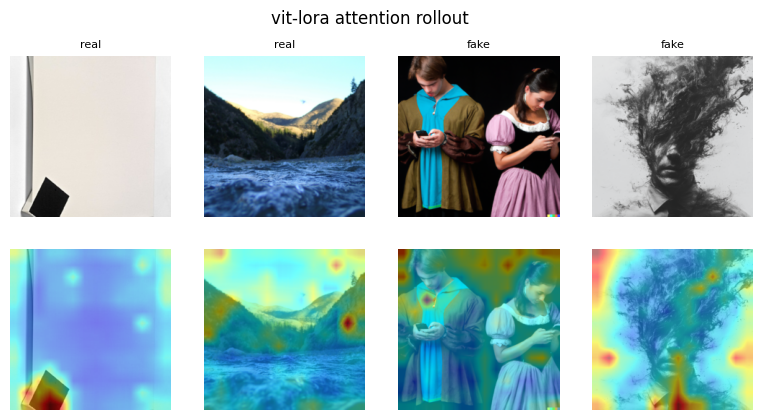

In [7]:
if "vit-lora" in PIPES:
    from pytorch_grad_cam.utils.image import show_cam_on_image
    sp = EP.SPEC["vit-lora"]; mean, std = D.resolve_stats(sp["norm"], EP.AIR)
    eval_tf = D.build_eval_tf(sp["size"], mean, std)
    model = EP.load_model("vit-lora", device)
    fig, axes = plt.subplots(2, len(examples), figsize=(2.4 * len(examples), 4.6))
    for col, ex in enumerate(examples):
        arr = eda.read_rgb(ex["filepath"]); xt = eval_tf(torch.from_numpy(arr).permute(2, 0, 1)); x = xt.unsqueeze(0).to(device)
        rgb = D.denormalize(xt, mean, std).permute(1, 2, 0).numpy()
        mask = E.attention_rollout(model, x, out_size=sp["size"])
        overlay = show_cam_on_image(np.ascontiguousarray(rgb, dtype=np.float32), mask, use_rgb=True)
        axes[0, col].imshow(rgb); axes[0, col].axis("off"); axes[0, col].set_title(ex["label"], fontsize=8)
        axes[1, col].imshow(overlay); axes[1, col].axis("off")
    fig.suptitle("vit-lora attention rollout", fontsize=12)
    fig.savefig(OUT / "vit_attention_rollout.png", dpi=150, bbox_inches="tight"); plt.show()
    del model
else:
    print("vit-lora not available")

## 3 - CLIP-probe embedding t-SNE

Why CLIP-probe tends to generalize: real vs fake separability in the frozen embedding space.

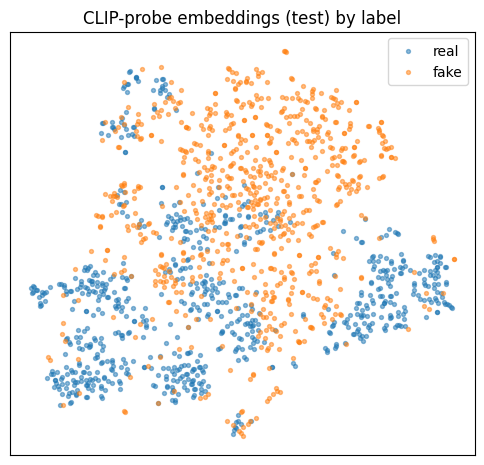

In [8]:
if "clip-probe" in PIPES and (EP.AIR / "clip_emb_test.npy").exists():
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    emb = np.load(EP.AIR / "clip_emb_test.npy"); lab = EP.split_labels("test")
    rng = np.random.RandomState(42); idx = rng.choice(len(emb), size=min(1500, len(emb)), replace=False)
    Xp = PCA(n_components=50, random_state=42).fit_transform(StandardScaler().fit_transform(emb[idx]))
    xy = TSNE(n_components=2, init="pca", perplexity=30, random_state=42).fit_transform(Xp)
    labs = np.where(lab[idx] > 0.5, "fake", "real")
    fig, ax = plt.subplots(figsize=(6, 5.5))
    for v in ["real", "fake"]:
        m = labs == v; ax.scatter(xy[m, 0], xy[m, 1], s=8, alpha=0.5, label=v)
    ax.legend(); ax.set_title("CLIP-probe embeddings (test) by label"); ax.set_xticks([]); ax.set_yticks([])
    fig.savefig(OUT / "clip_tsne.png", dpi=150, bbox_inches="tight"); plt.show()
else:
    print("clip-probe embeddings not available")

## 4 - Notes

- `patch-ensemble` explainability = per-patch MIL attention weights (see its own notebook's `patch_attention.png`).
- `dire-recon` explainability = the DIRE reconstruction-error maps themselves (`dire_maps.png`).
- Frequency-spectrum real-vs-fake motivation is in `01_eda` (`05_*` figures) and drives `two-stream`/`freqcross`.